In [27]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti


In [28]:
import os
import numpy as np
import pandas as pd
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from tqdm import tqdm

In [29]:
DATA_DIR = "../datasets/processed"

def load_all_datasets():
    paths = {
        'imdb': os.path.join(DATA_DIR, 'imdb.csv'),
        'rotten': os.path.join(DATA_DIR, 'rotten.csv'),
        'amazon': os.path.join(DATA_DIR, 'amazon.csv'),
        'yelp': os.path.join(DATA_DIR, 'yelp.csv')
    }

    datasets = {}

    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Nie znaleziono pliku: {path}")

        df = pd.read_csv(path)
        df = df[['text', 'label']].dropna()
        df['label'] = df['label'].astype(int)
        datasets[name] = df

    return datasets

datasets = load_all_datasets()

for domain, df in datasets.items():
    print(f"{domain}: {len(df)} samples")

imdb: 50000 samples
rotten: 49999 samples
amazon: 21055 samples
yelp: 10000 samples


In [30]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded. Max length: {MAX_LEN}")

Tokenizer loaded. Max length: 128


In [31]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            padding="max_length",
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

In [32]:
def build_distilbert():
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
    return model.to(device)

In [33]:
def train_model(model, train_loader, val_loader, epochs=3):
    optimizer = AdamW(model.parameters(), lr=2e-5)
    scaler = GradScaler(device.type)

    best_val_loss = float("inf")
    patience = 2
    patience_counter = 0

    history_rows = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        # TRAIN
        model.train()
        total_loss = 0.0

        for batch in tqdm(train_loader):
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=device.type):
                outputs = model(**batch)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        avg_train_loss = total_loss / max(1, len(train_loader))

        # VALIDATION
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                val_loss += outputs.loss.item()

        avg_val_loss = val_loss / max(1, len(val_loader))

        print(f"Train loss: {avg_train_loss:.4f} | Val loss: {avg_val_loss:.4f}")

        history_rows.append({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss
        })

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break

    return pd.DataFrame(history_rows)

In [34]:
def predict(model, loader):
    model.eval()
    preds = []

    with torch.no_grad():
        for batch in loader:
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            outputs = model(**inputs)
            logits = outputs.logits
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy().tolist())

    return np.array(preds)

In [35]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

In [36]:
def run_ood_experiment_distilbert(
    datasets,
    epochs=3,
    batch_size=32,
    n_splits=5
):
    results = []
    training_logs = []

    domains = list(datasets.keys())

    for train_domain in domains:
        print("\n" + "="*80)
        print(f"TRAIN DOMAIN: {train_domain}")
        print("="*80)

        df = datasets[train_domain].reset_index(drop=True)

        X_text = df["text"].values
        y = df["label"].values.astype(int)

        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        for fold_id, (train_idx, val_idx) in enumerate(kf.split(X_text, y), 1):
            print(f"\nFold {fold_id}/{n_splits}")

            train_dataset = TextDataset(
                X_text[train_idx], y[train_idx], tokenizer, MAX_LEN
            )
            val_dataset = TextDataset(
                X_text[val_idx], y[val_idx], tokenizer, MAX_LEN
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True,
                pin_memory=(device.type == "cuda")
            )
            val_loader = DataLoader(
                val_dataset,
                batch_size=batch_size,
                shuffle=False,
                pin_memory=(device.type == "cuda")
            )

            model = build_distilbert()

            fold_history = train_model(model, train_loader, val_loader, epochs=epochs)
            for _, row in fold_history.iterrows():
                training_logs.append({
                    "train_domain": train_domain,
                    "fold": fold_id,
                    "epoch": int(row["epoch"]),
                    "train_loss": float(row["train_loss"]),
                    "val_loss": float(row["val_loss"])
                })

            # =========================
            # IN-DOMAIN
            # =========================
            y_val = y[val_idx]
            preds = predict(model, val_loader)

            metrics = compute_metrics(y_val, preds)

            results.append({
                "train_domain": train_domain,
                "test_domain": train_domain,
                "fold": fold_id,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "eval_type": "IND"
            })

            print(f"IND | F1: {metrics['f1']:.4f} | Acc: {metrics['accuracy']:.4f} | Prec: {metrics['precision']:.4f} | Rec: {metrics['recall']:.4f}")

            # =========================
            # OOD
            # =========================
            for test_domain, test_df in datasets.items():
                if test_domain == train_domain:
                    continue

                X_test_text = test_df["text"].values
                y_test = test_df["label"].values.astype(int)

                test_dataset = TextDataset(
                    X_test_text, y_test, tokenizer, MAX_LEN
                )
                test_loader = DataLoader(
                    test_dataset,
                    batch_size=batch_size,
                    shuffle=False,
                    pin_memory=(device.type == "cuda")
                )

                preds = predict(model, test_loader)
                metrics = compute_metrics(y_test, preds)

                results.append({
                    "train_domain": train_domain,
                    "test_domain": test_domain,
                    "fold": fold_id,
                    "accuracy": metrics["accuracy"],
                    "precision": metrics["precision"],
                    "recall": metrics["recall"],
                    "f1": metrics["f1"],
                    "eval_type": "OOD"
                })

                print(f"OOD {train_domain} → {test_domain} | F1: {metrics['f1']:.4f} | Acc: {metrics['accuracy']:.4f}")

            del model, train_loader, val_loader, train_dataset, val_dataset
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()

    return pd.DataFrame(training_logs), pd.DataFrame(results)

In [37]:
training_logs_distilbert, ood_results_distilbert = run_ood_experiment_distilbert(
    datasets=datasets,
    epochs=3,
    batch_size=32,
    n_splits=5
)


TRAIN DOMAIN: imdb

Fold 1/5


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 21759.20it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/3


100%|██████████| 1250/1250 [00:48<00:00, 25.87it/s]


Train loss: 0.3249 | Val loss: 0.2750

Epoch 2/3


...

Train loss: 0.2858 | Val loss: 0.2212

Epoch 2/3


100%|██████████| 250/250 [00:09<00:00, 25.85it/s]


Train loss: 0.1770 | Val loss: 0.2151

Epoch 3/3


100%|██████████| 250/250 [00:09<00:00, 25.87it/s]


Train loss: 0.0974 | Val loss: 0.2935
IND | F1: 0.9473 | Acc: 0.9100 | Prec: 0.9240 | Rec: 0.9718
OOD yelp → imdb | F1: 0.7848 | Acc: 0.7385
OOD yelp → rotten | F1: 0.7380 | Acc: 0.6672
OOD yelp → amazon | F1: 0.7862 | Acc: 0.8571


In [38]:
SAVE_DIR = "./results"
os.makedirs(SAVE_DIR, exist_ok=True)

training_logs_distilbert.to_csv(os.path.join(SAVE_DIR, "distilbert_training_logs.csv"), index=False)
ood_results_distilbert.to_csv(os.path.join(SAVE_DIR, "distilbert_ood_results.csv"), index=False)

print("Saved:")
print(" - distilbert_training_logs.csv")
print(" - distilbert_ood_results.csv")

Saved:
 - distilbert_training_logs.csv
 - distilbert_ood_results.csv


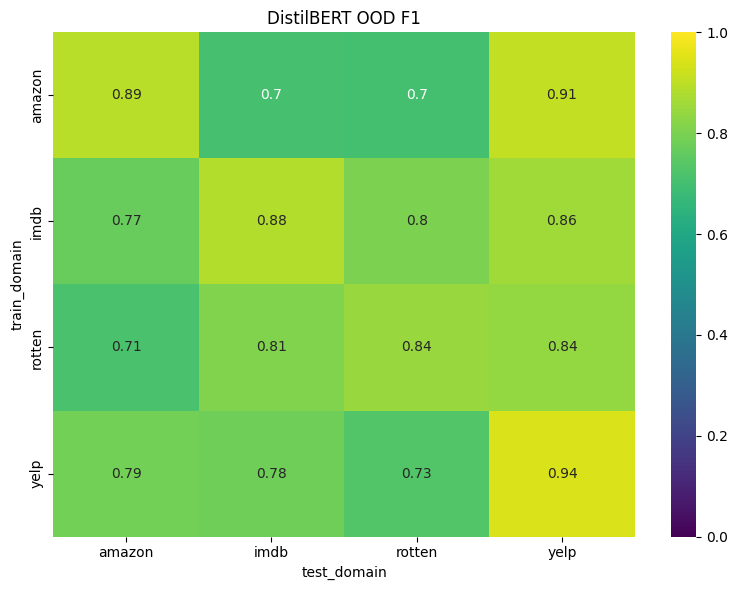

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = ood_results_distilbert.groupby(
    ["train_domain", "test_domain"]
)["f1"].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("DistilBERT OOD F1")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

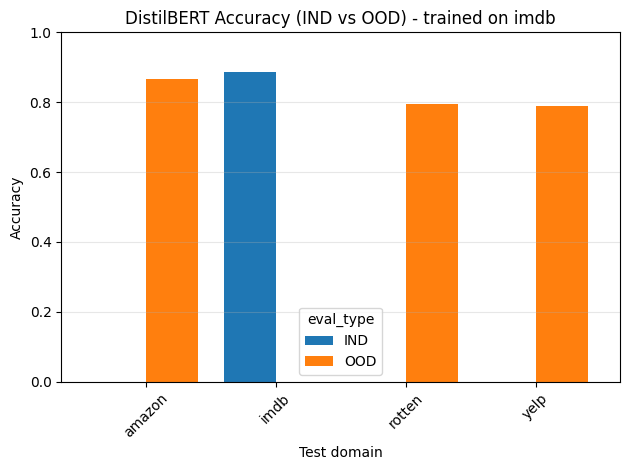

<Figure size 1000x500 with 0 Axes>

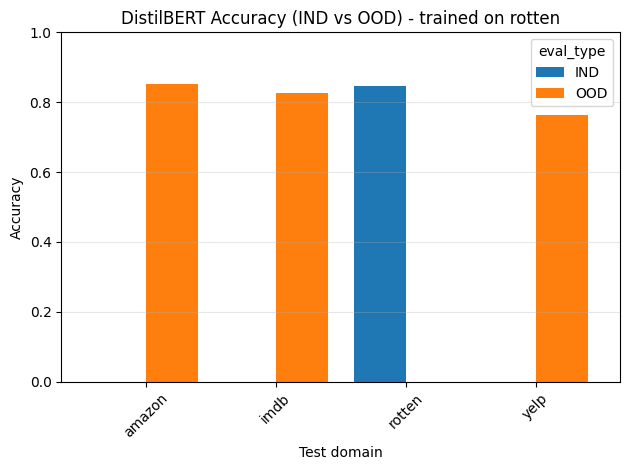

<Figure size 1000x500 with 0 Axes>

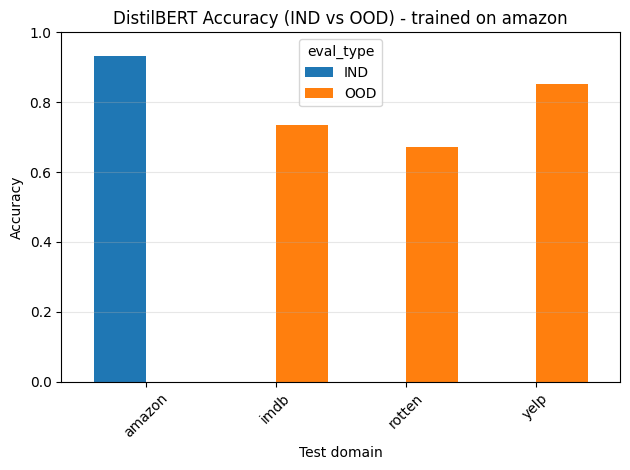

<Figure size 1000x500 with 0 Axes>

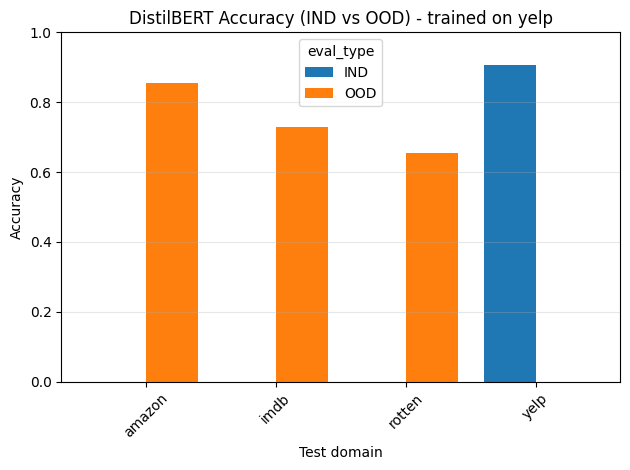

In [40]:
train_domains = ood_results_distilbert["train_domain"].unique()

for train_domain in train_domains:
    subset = ood_results_distilbert[ood_results_distilbert["train_domain"] == train_domain]

    pivot = subset.pivot_table(
        index="test_domain",
        columns="eval_type",
        values="accuracy",
        aggfunc="mean"
    )

    pivot = pivot.sort_index()

    plt.figure(figsize=(10, 5))
    ax = pivot.plot(kind="bar", width=0.8)

    plt.title(f"DistilBERT Accuracy (IND vs OOD) - trained on {train_domain}")
    plt.xlabel("Test domain")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

plt.show()